<a href="https://colab.research.google.com/github/samarreguigui/AI_Ethik/blob/main/10_grok_us_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 — Grok vs. the US field (house-style control)

**Idea.** Hold *country* fixed (all USA) and ask whether Grok — xAI's model, marketed as
less filtered and partly trained on X — classifies and steers differently from the other
US models you already ran.

This notebook **only runs Grok**. Every other model is *loaded from results you already
saved*

- **Part A — Classification.** Identical dataset / prompt / parser / directional-bias score
  as notebook 09. Grok joins Claude Haiku, GPT-4o-mini and Llama 3.3 70B (the three USA models).


## 0 · Setup, keys, and Grok config

In [ ]:
%pip install -q openai numpy pandas matplotlib seaborn tqdm pyarrow

In [ ]:
import os, time, json, logging
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from openai import OpenAI, RateLimitError

from google.colab import drive
drive.mount('/content/drive')

logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(levelname)s  %(message)s')
log = logging.getLogger(__name__)

DRIVE = Path('/content/drive/MyDrive/Master thesis')
with open(DRIVE / 'openai_key.txt') as f:
    OPENAI_API_KEY = f.read().strip()
with open(DRIVE / 'openrouter_key.txt') as f:
    OPENROUTER_API_KEY = f.read().strip()

openai_client = OpenAI(api_key=OPENAI_API_KEY)
router_client = OpenAI(
    base_url='https://openrouter.ai/api/v1',
    api_key=OPENROUTER_API_KEY,
    default_headers={'HTTP-Referer': 'https://colab.research.google.com',
                     'X-Title': 'Master Thesis Bias Study'},
)

# Grok config (the ONLY model this notebook actually calls)
GROK_NAME          = 'Grok'
GROK_COUNTRY       = 'USA'
GROK_CLASSIFY_SLUG = 'x-ai/grok-4.3'    # Part A
GROK_GENERATE_SLUG = 'x-ai/grok-4.3'    # Part B  (set equal to remove capability confound)
GROK_KEY           = 'grok'             # short key used in steerability tables

print('Setup OK - Grok:', GROK_CLASSIFY_SLUG)


---
# Part A — Classification (US house-style)


## A1 · Dataset helpers (raw corpus fetched *only* if the test set must be rebuilt)

Normal runs load the saved `test_set_all_topics.parquet` in A2 and never touch these.


In [ ]:
def ensure_raw_corpus():
    """Clone the raw AllSides repo. Only called if the saved test set is missing."""
    repo = Path('/content/Article-Bias-Prediction')
    if not repo.exists():
        print('Cloning dataset (~30s)...')
        os.system(f'git clone https://github.com/ramybaly/Article-Bias-Prediction.git "{repo}"')
    print('JSON files:', len(list((repo / "data" / "jsons").glob("*.json"))))
    return repo


In [ ]:
DATA_DIR   = Path('/content/Article-Bias-Prediction')
JSONS_DIR  = DATA_DIR / 'data' / 'jsons'
THESIS_DIR = DRIVE
CACHE_PATH = THESIS_DIR / 'allsides_articles.parquet'

# OUTPUT: the folder you created for this Grok study (everything Grok writes goes here)
OUTPUT_DIR = DRIVE / '10_Grok_comparison'         # <-- your new folder; edit if named differently
PLOTS_DIR  = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# INPUTS: where notebook 09 already wrote (read-only)
NB09_DIR          = THESIS_DIR / '09_all_topics_run'
NB09_RESULTS_PATH = NB09_DIR / 'results_all_topics.csv'       # other models' per-article preds
TEST_SET_PATH     = NB09_DIR / 'test_set_all_topics.parquet'  # identical test set

RANDOM_SEED        = 42
ARTICLES_PER_LABEL = 30
BIAS_NUM_TO_STR    = {0: 'Left', 1: 'Center', 2: 'Right'}
BIAS_STR_TO_SCORE  = {'Left': -1, 'Center': 0, 'Right': 1}
TOPIC_ORDER        = ['Politics', 'Economics', 'Religion', 'Gender', 'Environment']

print('OUTPUT (Grok writes here):', OUTPUT_DIR)
print('INPUT  (other models):    ', NB09_RESULTS_PATH)


OUTPUT (Grok writes here): /content/drive/MyDrive/Master thesis/10_Grok_comparison
INPUT  (other models):     /content/drive/MyDrive/Master thesis/09_all_topics_run/results_all_topics.csv


In [ ]:
def load_articles(jsons_dir, cache_path=None):
    if cache_path is not None and cache_path.exists():
        print('Loading from cache:', cache_path)
        return pd.read_parquet(cache_path)
    rows = []
    files = list(jsons_dir.glob('*.json'))
    print(f'Found {len(files):,} JSON files')
    for f in tqdm(files, desc='Loading'):
        try:
            with open(f, 'r', encoding='utf-8') as fh:
                a = json.load(fh)
            rows.append({'id': a.get('ID'),
                         'topic': (a.get('topic') or '').lower(),
                         'source': a.get('source'),
                         'title': a.get('title'),
                         'content': a.get('content_original') or a.get('content') or '',
                         'bias_num': a.get('bias')})
        except Exception as e:
            print('Skipping', f.name, e)
    df = pd.DataFrame(rows)
    df['bias_label'] = df['bias_num'].map(BIAS_NUM_TO_STR)
    if cache_path is not None:
        df.to_parquet(cache_path)
    return df


## A2 · Reuse the *exact* notebook-09 test set
Loads the saved `test_set_all_topics.parquet` so Grok sees the identical articles. Only
rebuilds it (same seed / topic groups) if that file is missing.

In [ ]:
GENDER_TOPICS      = ["abortion", "lgbt_rights", "women's_issues", "sexual_misconduct", "family_and_marriage"]
ENVIRONMENT_TOPICS = ["environment", "energy"]
POLITICS_TOPICS    = ["elections", "politics", "white_house", "polarization", "republican_party",
                      "us_congress", "us_senate", "us_house", "impeachment", "democratic_party",
                      "campaign_finance", "campaign_rhetoric", "voting_rights_and_voter_fraud"]
RELIGION_TOPICS    = ["religion_and_faith"]
ECONOMICS_TOPICS   = ["economy_and_jobs", "federal_budget", "taxes", "trade", "banking_and_finance",
                      "economic_policy", "fiscal_cliff", "labor", "treasury", "inequality",
                      "social_security", "welfare", "housing_and_homelessness"]
THESIS_TOPICS = {"Gender": GENDER_TOPICS, "Environment": ENVIRONMENT_TOPICS,
                 "Politics": POLITICS_TOPICS, "Religion": RELIGION_TOPICS, "Economics": ECONOMICS_TOPICS}

if TEST_SET_PATH.exists():
    df_test = pd.read_parquet(TEST_SET_PATH)
    print(f'Loaded saved test set: {len(df_test)} articles (identical to notebook 09)')
else:
    print('Saved test set not found - rebuilding with the same seed/topics.')
    ensure_raw_corpus()
    df_all = load_articles(JSONS_DIR, cache_path=CACHE_PATH)
    all_samples = []
    for topic_name, topic_list in THESIS_TOPICS.items():
        df_t = df_all[df_all['topic'].isin(topic_list)].copy()
        df_t = df_t[df_t['content'].str.len() > 200].copy()
        df_t['thesis_topic'] = topic_name
        for label in ['Left', 'Center', 'Right']:
            pool = df_t[df_t['bias_label'] == label]
            n = min(ARTICLES_PER_LABEL, len(pool))
            if n < ARTICLES_PER_LABEL:
                print(f'WARNING: {topic_name}/{label} only {len(pool)}')
            all_samples.append(pool.sample(n=n, random_state=RANDOM_SEED))
    df_test = pd.concat(all_samples).reset_index(drop=True)
    df_test.to_parquet(OUTPUT_DIR / 'test_set_all_topics.parquet')
print(df_test.groupby(['thesis_topic', 'bias_label']).size().unstack(fill_value=0))


Saved test set not found - rebuilding with the same seed/topics.
Cloning dataset (~30s)...
JSON files: 37554
Loading from cache: /content/drive/MyDrive/Master thesis/data/allsides_articles.parquet
bias_label    Center  Left  Right
thesis_topic                     
Economics         30    30     30
Environment       30    30     30
Gender            30    30     30
Politics          30    30     30
Religion          30    30     30


## A3 · Prompt + parser (verbatim from notebook 09)

In [ ]:
def build_prompt(article_text='', title='', source=''):
    return ("Classify the political leaning of the following news article. "
            "Respond with exactly one word: Left, Centre, or Right.\n\n"
            f"Title: {title}\n"
            f"Source: {source}\n\n"
            "Classification:")

def parse_label(raw):
    if raw.startswith('ERROR'):
        return 'Error'
    r = raw.strip().lower()
    refusal_markers = ['cannot', "can't", 'unable', 'refuse', "i don't", 'as an ai', 'no political']
    if any(m in r for m in refusal_markers):
        return 'Refused'
    head = r[:50]
    if 'left' in head and 'right' not in head and 'center' not in head and 'centre' not in head:
        return 'Left'
    if 'right' in head and 'left' not in head and 'center' not in head and 'centre' not in head:
        return 'Right'
    if ('center' in head or 'centre' in head) and 'left' not in head and 'right' not in head:
        return 'Center'
    return 'Other'

def query_model(model_slug, prompt, max_retries=3):
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = router_client.chat.completions.create(
                model=model_slug,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0, max_tokens=20)
            return (resp.choices[0].message.content or '').strip()
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    return f'ERROR: {last_err}'


## A3b · 🔍 Sanity check — preview Grok on a handful of articles
Run this **before** the full sweep. It calls Grok on ~6 articles (2 per true label) and
prints the raw response next to the parsed label, so you can confirm Grok returns clean
one-word answers (not refusals or essays) before spending on all ~450 calls.

In [ ]:
preview = (df_test.groupby('bias_label', group_keys=False)
           .apply(lambda g: g.sample(min(2, len(g)), random_state=0)))
print(f'Previewing {len(preview)} articles with {GROK_CLASSIFY_SLUG}\n')
for _, row in preview.iterrows():
    raw = query_model(GROK_CLASSIFY_SLUG, build_prompt(title=row['title'], source=row['source']))
    print(f"[{row['thesis_topic']:11s} | true={row['bias_label']:6s}] {str(row['source'])[:22]:22s} | {str(row['title'])[:55]}")
    print(f"     raw={raw!r}  ->  parsed={parse_label(raw)}\n")
print('If these look clean (one word, no refusals), run the full sweep below.')


/tmp/ipykernel_7596/637737555.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(2, len(g)), random_state=0)))


Previewing 6 articles with x-ai/grok-4.3

[Religion    | true=Center] Christian Science Moni | Jehovah's Witnesses as 'extremists': Court sharpens edg
     raw='Centre'  ->  parsed=Center

[Politics    | true=Center] Christian Science Moni | Trump rides rural rebellion to stunning victory
     raw='Centre\n\n\nThe Christian Science Monitor is widely rated as a least-biased, centrist outlet whose editorial'  ->  parsed=Center

[Religion    | true=Left  ] Salon                  | Civil war in the church!: Catholics tell bishops to sto
     raw='Left\n\n\nThe source (Salon) is a well-documented progressive outlet whose editorial stance consistently favors left'  ->  parsed=Left

[Politics    | true=Left  ] Politico               | 'The surge is real': Klobuchar makes late push in Iowa
     raw='Centre\n\n\nThe title and source alone indicate neutral campaign reporting on a moderate Democrat from Politico, an'  ->  parsed=Center

[Religion    | true=Right ] CBN                    | 'Faith 

## A4 · Run **Grok only** over the test set
Checkpoints to `grok_results_all_topics.csv`; re-running resumes where it left off.

In [ ]:
GROK_RESULTS_PATH = OUTPUT_DIR / 'grok_results_all_topics.csv'

if GROK_RESULTS_PATH.exists():
    grok_rows = pd.read_csv(GROK_RESULTS_PATH).to_dict('records')
    done_ids = {r['article_id'] for r in grok_rows}
    print(f'Resuming - {len(grok_rows)} Grok rows already saved')
else:
    grok_rows, done_ids = [], set()

print(f'=== {GROK_NAME} ({GROK_COUNTRY}) :: {GROK_CLASSIFY_SLUG} ===')
for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc=GROK_NAME):
    if row['id'] in done_ids:
        continue
    prompt = build_prompt(title=row['title'], source=row['source'])
    raw = query_model(GROK_CLASSIFY_SLUG, prompt)
    grok_rows.append({'model': GROK_NAME, 'country': GROK_COUNTRY,
                      'thesis_topic': row['thesis_topic'], 'article_id': row['id'],
                      'true_label': row['bias_label'], 'raw_response': raw,
                      'predicted_label': parse_label(raw)})
    if len(grok_rows) % 25 == 0:
        pd.DataFrame(grok_rows).to_csv(GROK_RESULTS_PATH, index=False)

df_grok = pd.DataFrame(grok_rows)
df_grok.to_csv(GROK_RESULTS_PATH, index=False)
print('Grok parse breakdown:'); print(df_grok['predicted_label'].value_counts())


## A5 · Combine with the other USA models (loaded, not re-run)

In [ ]:
df_other = pd.read_csv(NB09_RESULTS_PATH)
df_other_us = df_other[df_other['country'] == 'USA'].copy()
print('USA models loaded from notebook 09:', sorted(df_other_us['model'].unique()))

df_results = pd.concat([df_other_us, df_grok], ignore_index=True)
US_MODELS = list(df_results['model'].unique())
print('US comparison set:', US_MODELS)


USA models loaded from notebook 09: ['Claude Haiku', 'GPT-4o-mini', 'Llama 3.3 70B']
US comparison set: ['Claude Haiku', 'GPT-4o-mini', 'Llama 3.3 70B', 'Grok']


In [ ]:
def directional_bias(group):
    valid = group[group['predicted_label'].isin(['Left', 'Center', 'Right'])]
    if len(valid) == 0:
        return float('nan')
    return valid['predicted_label'].map(BIAS_STR_TO_SCORE).mean()

bias_scores = (df_results.groupby(['model', 'country', 'thesis_topic'])
               .apply(directional_bias, include_groups=False).reset_index())
bias_scores.columns = ['model', 'country', 'thesis_topic', 'bias_score']

bias_pivot = bias_scores.pivot_table(index=['model', 'country'],
                                     columns='thesis_topic', values='bias_score')
bias_pivot = bias_pivot[[t for t in TOPIC_ORDER if t in bias_pivot.columns]]
print(bias_pivot.round(3))

bias_scores.to_csv(OUTPUT_DIR / 'bias_scores_us_grok.csv', index=False)
bias_pivot.to_csv(OUTPUT_DIR / 'bias_pivot_us_grok.csv')


thesis_topic           Politics  Economics  Religion  Gender  Environment
model         country                                                    
Claude Haiku  USA         0.185      0.214     0.107   0.036       -0.024
GPT-4o-mini   USA        -0.122      0.044    -0.211  -0.289       -0.233
Grok          USA         0.022      0.022    -0.022  -0.044       -0.101
Llama 3.3 70B USA         0.078      0.144     0.022  -0.144       -0.122


## A6 · Directional-bias heatmap (US models, Grok highlighted)

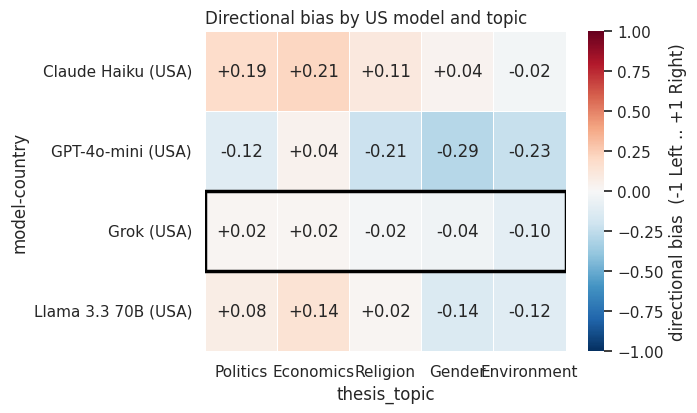

In [ ]:
plt.figure(figsize=(7, 0.7 * len(bias_pivot) + 1.5))
ax = sns.heatmap(bias_pivot, annot=True, fmt='+.2f', cmap='RdBu_r', center=0,
                 vmin=-1, vmax=1, cbar_kws={'label': 'directional bias  (-1 Left .. +1 Right)'},
                 linewidths=0.5, linecolor='white')
ylabels = [f'{m} ({c})' for m, c in bias_pivot.index]
for i, (m, c) in enumerate(bias_pivot.index):
    if m == GROK_NAME:
        ax.add_patch(plt.Rectangle((0, i), bias_pivot.shape[1], 1, fill=False, edgecolor='black', lw=2.5))
ax.set_yticklabels(ylabels, rotation=0)
plt.title('Directional bias by US model and topic', loc='left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'us_grok_bias_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


## A7 · Per-topic bar chart (same style as notebook 09)

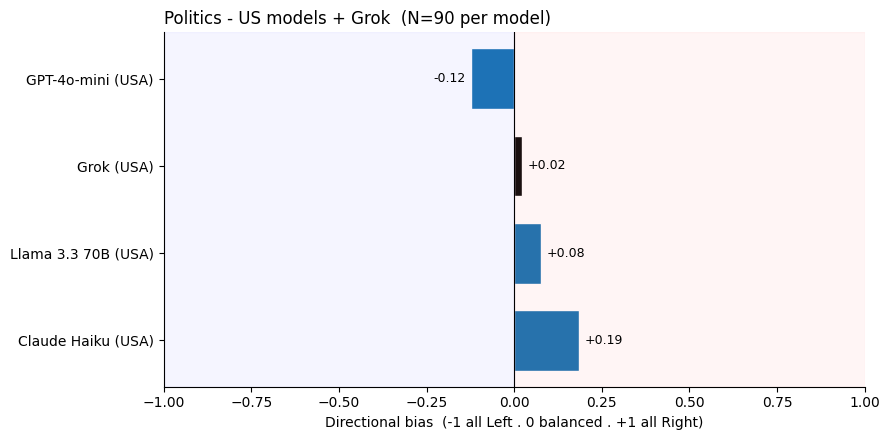

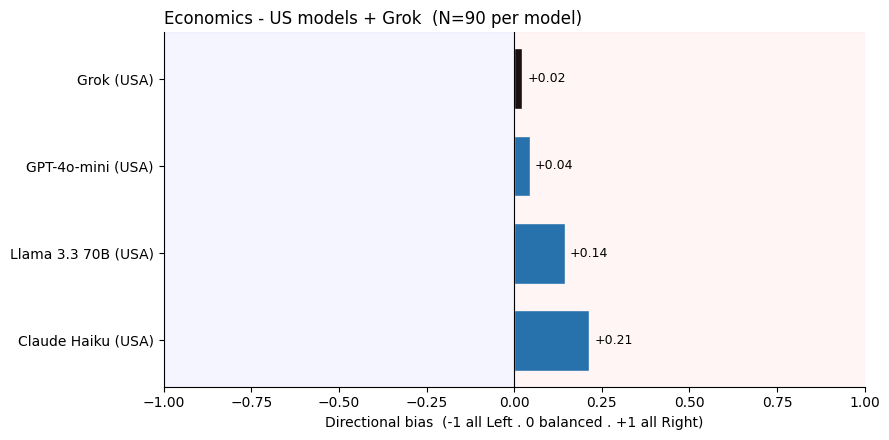

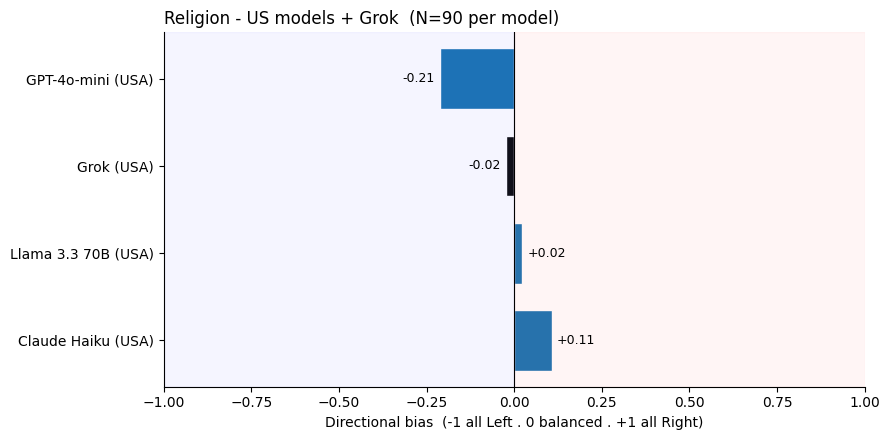

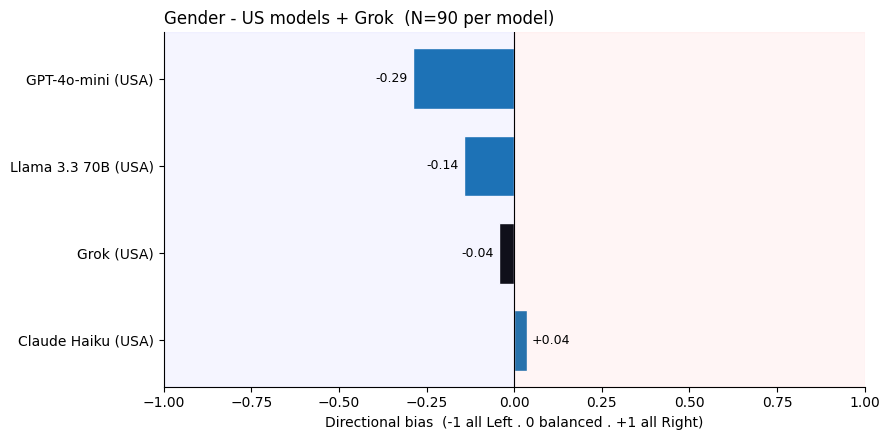

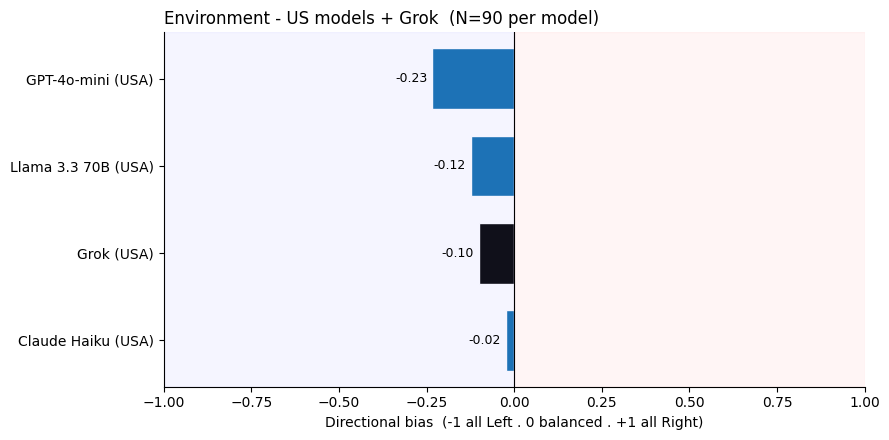

In [ ]:
GROK_COLOR, OTHER_COLOR = '#111111', '#1f77b4'
for topic in TOPIC_ORDER:
    bt = bias_scores[bias_scores['thesis_topic'] == topic]
    if bt.empty:
        continue
    sd = bt.sort_values('bias_score').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    y = np.arange(len(sd))
    colors = [GROK_COLOR if m == GROK_NAME else OTHER_COLOR for m in sd['model']]
    vals = sd['bias_score'].values
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y); ax.set_yticklabels([f'{m} ({c})' for m, c in zip(sd['model'], sd['country'])])
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v + (-0.015 if v < 0 else 0.015), i, f'{v:+.2f}', va='center',
                ha='right' if v < 0 else 'left', fontsize=9)
    ax.axvline(0, color='black', lw=0.8); ax.set_xlim(-1, 1)
    ax.axvspan(-1, 0, alpha=0.04, color='blue'); ax.axvspan(0, 1, alpha=0.04, color='red')
    ax.set_xlabel('Directional bias  (-1 all Left . 0 balanced . +1 all Right)')
    n = len(df_test[df_test['thesis_topic'] == topic])
    ax.set_title(f'{topic} - US models + Grok  (N={n} per model)', loc='left')
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'us_grok_bias_{topic.lower()}.png', dpi=200, bbox_inches='tight')
    plt.show()


In [ ]:
VALID = ['Left', 'Center', 'Right']
d = df_grok.copy()

n          = len(d)
answered   = d['predicted_label'].isin(VALID)
n_answered = answered.sum()
correct    = (d['predicted_label'] == d['true_label']) & answered

print(f"Total articles      : {n}")
print(f"Got an answer       : {n_answered} ({n_answered/n:.1%})")
print(f"No usable answer    : {n-n_answered} ({(n-n_answered)/n:.1%})")
print(f"Correct (overall)   : {correct.sum()} ({correct.sum()/n:.1%})")
print(f"Correct (of answered): {correct.sum()}/{n_answered} "
      f"({correct.sum()/n_answered:.1%})" if n_answered else "n/a")

print("\nBreakdown of non-answers:")
print(d.loc[~answered, 'predicted_label'].value_counts())

Total articles      : 450
Got an answer       : 448 (99.6%)
No usable answer    : 2 (0.4%)
Correct (overall)   : 357 (79.3%)
Correct (of answered): 357/448 (79.7%)

Breakdown of non-answers:
predicted_label
Other    2
Name: count, dtype: int64


In [ ]:
VALID = ['Left', 'Center', 'Right']

other = pd.read_csv(NB09_RESULTS_PATH)
allm  = pd.concat([other, df_grok], ignore_index=True)   # + Grok

allm['answered'] = allm['predicted_label'].isin(VALID)
allm['correct']  = allm['answered'] & (allm['predicted_label'] == allm['true_label'])

# overall metrics
summary = (allm.groupby(['model', 'country'])
           .agg(n=('predicted_label', 'size'),
                answered=('answered', 'sum'),
                correct=('correct', 'sum'))
           .reset_index())
summary['answer_rate_%']     = (summary['answered'] / summary['n'] * 100).round(1)
summary['acc_overall_%']     = (summary['correct']  / summary['n'] * 100).round(1)
summary['acc_of_answered_%'] = (summary['correct']  / summary['answered'].replace(0, pd.NA) * 100).round(1)

# per-class accuracy: of true L/C/R, how many predicted correctly
def class_acc(g, label):
    sub = g[g['true_label'] == label]
    return (sub['predicted_label'] == label).mean() * 100 if len(sub) else float('nan')

per_class = (allm.groupby(['model', 'country'])
             .apply(lambda g: pd.Series({
                 'acc_Left_%':   round(class_acc(g, 'Left'),   1),
                 'acc_Center_%': round(class_acc(g, 'Center'), 1),
                 'acc_Right_%':  round(class_acc(g, 'Right'),  1),
             }), include_groups=False)
             .reset_index())

summary = summary.merge(per_class, on=['model', 'country']).sort_values('acc_overall_%', ascending=False)
print(summary[['model', 'country', 'n', 'answer_rate_%', 'acc_overall_%', 'acc_of_answered_%',
               'acc_Left_%', 'acc_Center_%', 'acc_Right_%']].to_string(index=False))

          model country   n  answer_rate_%  acc_overall_%  acc_of_answered_%  acc_Left_%  acc_Center_%  acc_Right_%
           Grok     USA 450           99.6           79.3               79.7        80.0          59.3         98.7
   Claude Haiku     USA 450           92.7           76.4               82.5        70.0          61.3         98.0
Jamba Large 1.7  Israel 450          100.0           74.4               74.4        42.7          83.3         97.3
  Llama 3.3 70B     USA 450          100.0           72.7               72.7        63.3          71.3         83.3
    DeepSeek V3   China 450          100.0           72.2               72.2        47.3          78.0         91.3
  Mistral Small  France 450          100.0           70.9               70.9        29.3          94.7         88.7
   Qwen 2.5 72B   China 450          100.0           68.0               68.0        44.0          77.3         82.7
     Command R+  Canada 450           99.8           65.6               